# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 2     |  |
| :-------------|:-------------|
| Sriman Patlolla| 6393829 |
| Berend Nettl| 6581226 |
| Niels van Meurs| 6190243 |
| Planning Groep: 2     |Tijdstip / Tijdspanne  |
| Mijlpaal 1|Sanity checks 10:45-12:00|
| Mijlpaal 2 | Ontwerpen van de sensor 12:00-12:20 |
| Mijlpaal 3 | Maken van sensor 13:20-14:00|
| Mijlpaal 4 | Simulatie/test 14:00-16:30 |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12:20-13:20 |
| Pauze 2| - |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
Bovenaan is een schets van onze plaatcondensator te zien. De waarde van A is 0.1 m^2 en de waarde van d is 2 mm.
<img src="Berekening.jpeg" alt="Schets plaatcondensator en berekening" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def functieNaam(A,d,epsilon):
    C=(8.85e-12*epsilon*A)/d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

#C = [functieNaam(2.0), functieNaam(4.7),functieNaam(1.2)]
C=functieNaam(0.01,2e-3,2.5)

print(f"Berekende capaciteit plaatcondensator groep 2 is {C} F")
V_berekend = C*10**3*2*np.pi*10**5*8
print(f"Berekend voltage is {V_berekend} V")




Berekende capaciteit plaatcondensator groep 2 is 1.10625e-10 F
Berekend voltage is 0.5560618996853934 V


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![Opstelling met de plaatcondensator](Opstelling.jpeg)
![Meting op de Oscilloscope](Scope.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 2| 110 pF|0.56 V | 0.7 V |140 pF|

## *Opdracht 2:* Synthese.

Schets 1 bepaalt gewicht door een foam in te laten drukken. Hier door verandert d en dus de capaciteit.
Schets 2 bepaalt gewicht door een plaat verbonden aan een elastiek te laten zakken. Hierdoor verandert A en dus de capaciteit.
Schets 3 bepaalt temperatuur door een ferroelektrisch materiaal tussen de platen te verwarmen. Hierdoor verandert epsilon en dus de capciteit.
![Schetsen 1 en 2](Schetsen1.jpeg)
![Schets 3](Schetsen2.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die gewicht meet door middel van een elastiek. Schets nummer 2 hierboven. Op een statief is een plaat vastgemaakt. De andere plaat zit aan een elastiek. Wanneer er gewicht op de elastiek wordt geplaatst, zal de plaat naar beneden schuiven en verandert het gemeenschappelijk oppervlak wat resulteert in een verandering van capaciteit. 

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Ontwerp.jpeg)

[46.3032 39.24   34.9236]


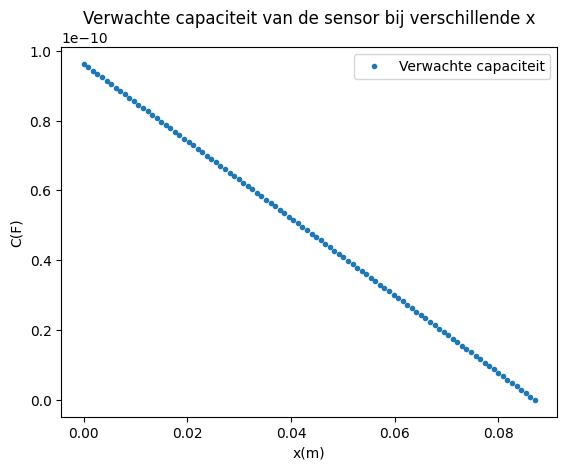

9.624375000000001e-11 0.0 4.812187500000001e-11


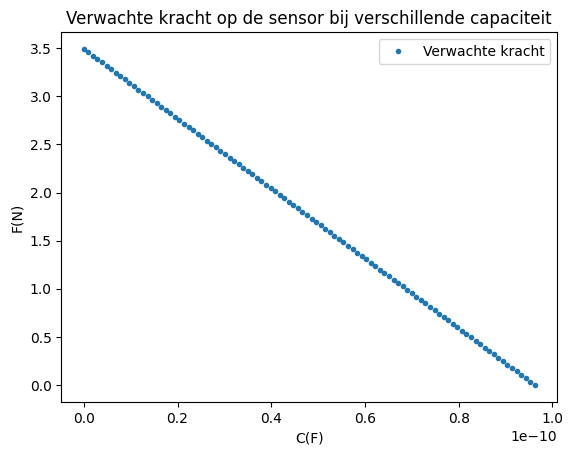

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
#Als plaat met x m omlaag gaat, is A_nieuw=A_oud-x*0.1
#Stuk karton tussen de platen blijft gelijk dus d_nieuw=d_oud. Ook blijft de f=110kHz en Vpp=16V
#En blijft epsilon_r ook gelijk

#Om de kracht/gewicht te bepalen hebben we veerconstante nodig en de uitrekking.
#Bij de metingen is de u gelijk aan x. Veerconstante is berekend met een aantal metingen met een krachtunster en meetlint aan de elastiek.
x=np.linspace(0,(0.1-0.013),100)
A_start = 0.1*(0.1-0.013)  #offset in contactoppervlak bij rustpositie daarvoor wordt gecompenseerd
A_nieuw = A_start - 0.1*x

C_nieuw = functieNaam(A_nieuw,2e-3,2.5)

#Bepalen Veerconstante
du = np.array([0.025,0.05,0.075])
F = 9.81* np.array([0.118,0.2,0.267])
C_veer1=F/du
print(C_veer1)
C_veer = np.mean(C_veer1)

#Zwaartekracht Fz = C_veer * u berekenen
Fz=C_veer*x


#plotten van de figuren
plt.figure()
plt.plot(x,C_nieuw,'.',label='Verwachte capaciteit')
plt.xlabel('x(m)')
plt.ylabel('C(F)')
plt.title('Verwachte capaciteit van de sensor bij verschillende x')
plt.legend()
plt.show()
print(np.max(C_nieuw),np.min(C_nieuw),np.mean(C_nieuw))

plt.figure()
plt.plot(C_nieuw,Fz,'.',label='Verwachte kracht')

plt.xlabel('C(F)')
plt.ylabel('F(N)')
plt.title('Verwachte kracht op de sensor bij verschillende capaciteit')
plt.legend()
plt.show()

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0 |0 |
| gemiddelde capaciteit| 48 |480 |
| maximale capaciteit| 96 |960 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![](Actie.jpeg)
![meting 2](Werkend.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

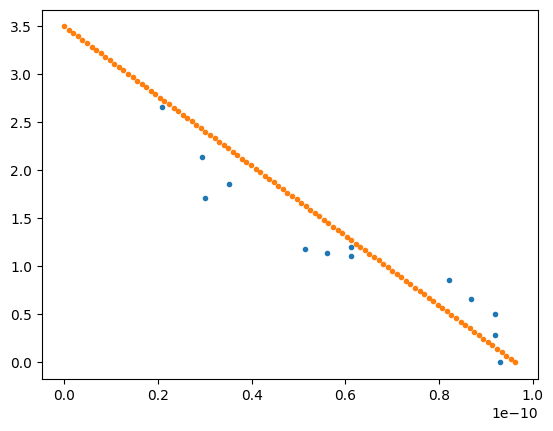

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.
Capaciteit = np.array([93,92,35.2,29.3,20.8,92,82.1,56,61.3,30,51.4,86.8,61.2])*1e-12
g = np.array([0,29,189.1,218.1,270.1,50.8,86.8,115.8,122.3,174.3,120.3,66.6,112.6])*9.81/1000


plt.figure()
plt.plot(Capaciteit,g,'.',label='Gemeten data')
plt.plot(C_nieuw,Fz,'.',label='Verwachte data')



## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1: Grotere platen om het bereik van de condensator en zo het bereik van de sensor te vergroten
* verbetering 2: Opstelling verbeteren zodat er minder ruis is. Nu is soms bijv een plaat scheef of het gewicht is niet goed op te zetten. De volgende keer deze punten verbeteren.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto uiteindelijke sensor](Werkend.jpeg)

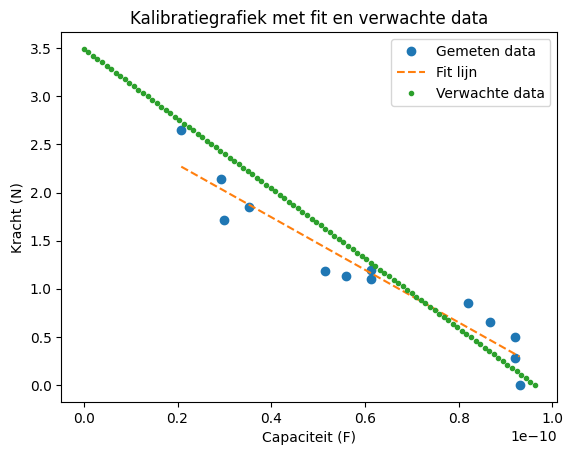

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
Capaciteit = np.array([93,92,35.2,29.3,20.8,92,82.1,56,61.3,30,51.4,86.8,61.2])*1e-12
g = np.array([0,29,189.1,218.1,270.1,50.8,86.8,115.8,122.3,174.3,120.3,66.6,112.6])*9.81/1000

def func(x, a, b):
    return a*x + b
popt, pcov = curve_fit(func, Capaciteit, g,p0=[-2.8e10,2.5])

Cap_test = np.linspace(min(Capaciteit), max(Capaciteit), 100)
g_fit = func(Cap_test, *popt)
plt.figure()
plt.plot(Capaciteit, g, 'o', label='Gemeten data')
plt.plot(Cap_test, g_fit, '--', label='Fit lijn')
plt.plot(C_nieuw, Fz, '.', label='Verwachte data')

plt.xlabel('Capaciteit (F)')
plt.ylabel('Kracht (N)')
plt.title('Kalibratiegrafiek met fit en verwachte data')
plt.legend()
plt.show()



## Opdracht 10: Vul hieronder de conclusie in.

De gebouwde sensor werkt. De sensor is alleen in zijn huidige staat niet heel nauwkeurig, maar er is wel een duidelijk verband tussen gewicht en capaciteit. De sensor kan nog verbeterd worden door grotere platen te gebruiken en de opstelling te verbeteren zodat er minder ruis is. Een stabieler ontwerp zou nauwkeuriger metingen opleveren. Tijdens de metingen was het ontwerp veel aan het bewegen en kon niet veel gewicht aan. Hierdoor zouden de metingen beinvloed kunnen zijn. De volgende keer zou het ontwerp dus stabieler moeten zijn en meer gewicht moeten kunnen dragen. Maar het bereik van de Capaciteit is wel goed te zien en er is een duidelijk verband tussen gewicht en capaciteit wat een goed teken is dat de sensor zou gebruikt kunnen worden om gewicht te meten.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

#### Voeg hier de foto's van je sensoren in actie in.
![](Actie.jpeg)
![meting 2](Werkend.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

#### Leerdoel 2 Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![Opstelling met de plaatcondensator](Opstelling.jpeg)
![Meting op de Oscilloscope](Scope.jpeg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

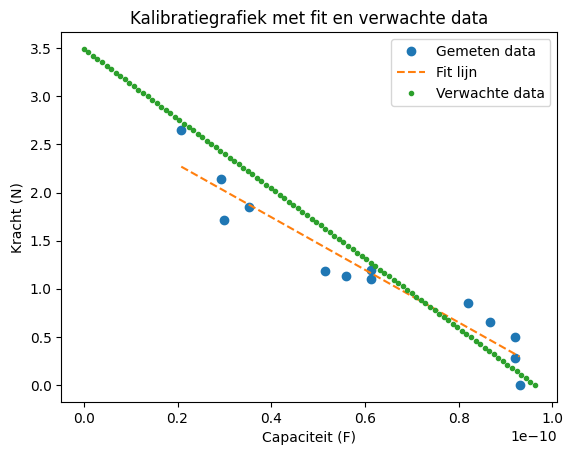

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
Capaciteit = np.array([93,92,35.2,29.3,20.8,92,82.1,56,61.3,30,51.4,86.8,61.2])*1e-12
g = np.array([0,29,189.1,218.1,270.1,50.8,86.8,115.8,122.3,174.3,120.3,66.6,112.6])*9.81/1000

def func(x, a, b):
    return a*x + b
popt, pcov = curve_fit(func, Capaciteit, g,p0=[-2.8e10,2.5])

Cap_test = np.linspace(min(Capaciteit), max(Capaciteit), 100)
g_fit = func(Cap_test, *popt)
plt.figure()
plt.plot(Capaciteit, g, 'o', label='Gemeten data')
plt.plot(Cap_test, g_fit, '--', label='Fit lijn')
plt.plot(C_nieuw, Fz, '.', label='Verwachte data')

plt.xlabel('Capaciteit (F)')
plt.ylabel('Kracht (N)')
plt.title('Kalibratiegrafiek met fit en verwachte data')
plt.legend()
plt.show()



De gebouwde sensor werkt. De sensor is alleen in zijn huidige staat niet heel nauwkeurig, maar er is wel een duidelijk verband tussen gewicht en capaciteit. De sensor kan nog verbeterd worden door grotere platen te gebruiken en de opstelling te verbeteren zodat er minder ruis is. Een stabieler ontwerp zou nauwkeuriger metingen opleveren. Tijdens de metingen was het ontwerp veel aan het bewegen en kon niet veel gewicht aan. Hierdoor zouden de metingen beinvloed kunnen zijn. De volgende keer zou het ontwerp dus stabieler moeten zijn en meer gewicht moeten kunnen dragen. Maar het bereik van de Capaciteit is wel goed te zien en er is een duidelijk verband tussen gewicht en capaciteit wat een goed teken is dat de sensor zou gebruikt kunnen worden om gewicht te meten.